#Task 1: Identifying the prediction target

##Target variable:
The target variable for this dataset is the "y" column as it is what confirms if a customer subscribed to a term deposit or not and it is a binary variable with options "yes" and "no".

This is the correct prediction objective because it directly represents the
outcome the bank is trying to forecast: given what is known about a client
*at the time of contact*, will they subscribe? Every other variable in the
dataset is either a descriptor of the client or a descriptor of the campaign
contact, y is the only column that captures the final outcome of interest.


## Variables That Could Be Mistaken for the Target

- poutcome: It could be confused as the variable are trying to predict as it has values such as "success", "failure" but this is not what we are triyng to predict because it is the result of a previous campaign not the current one so it could be used as a feature in predicting the actual target "y".

- duration: this column might seem useful to predict as when the call is longer there might be a higher chance that the client accepted and took the subscription but this is information not known at prediction time as it is recorded after the call thus it cannot be used as a feature and is not the predictive objective of the company.


#Task 2: Data Loading and Exploration

We load and inspect the data to see things like shape, missing values, and non values.


In [53]:
#Github repo: https://github.com/Allaawii/Assignment_1_ML_Foundations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
df = pd.read_csv('bank-additional.csv', sep=';') # Seperator in the dataset is ";"

In [3]:
df.shape

(4119, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [5]:
df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


##Categorical summary of the dataset:

In [6]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [7]:
numerical_features = df.select_dtypes(include=np.number).columns
print("Numerical Features:", numerical_features.tolist())

Numerical Features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


Our categorical features here are: 'job',	'marital',	'education',	'default',	'housing',	'loan',	'contact',	'month',	'day_of_week',	'poutcome'	and 'y' which is the prediction variable

Our numerical features are: 'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'

The dataset contains 4119 rows and 21 columns (20 features + 1 target).
Features are a mix of numerical and categorical types. No explicit NaN
values are reported by `.info()`, however this does not rule out implicit
missingness encoded as string values such as `"unknown"`.

y
no     3668
yes     451
Name: count, dtype: int64

Class ratio: 8.1:1 (no:yes)

Percentages: 89.05%, 10.95% (no:yes)


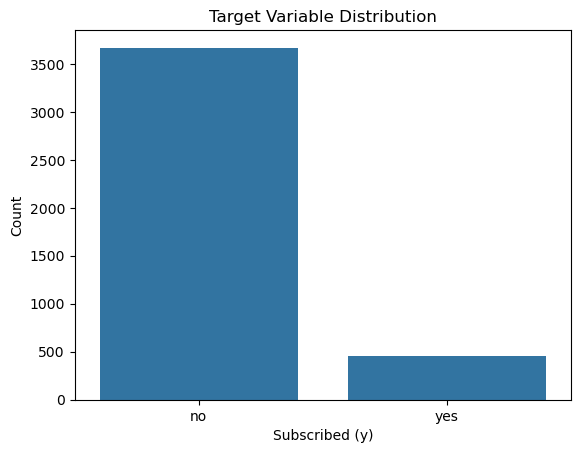

In [8]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print(target_counts)
print(f"\nClass ratio: {target_counts['no'] / target_counts['yes']:.1f}:1 (no:yes)")
print(f"\nPercentages: {target_pct['no']:.2f}%, {target_pct['yes']:.2f}% (no:yes)")

sns.countplot(x='y', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.show()

##Induction of target variable distribution:

The target variable is very unevenly distributed as the no has a 89% of the target variable so a dumb model could predict no every time and get 89% accuracy so we need to use precision, recall and F1 score to measure effectiveness. The learning algorithm may be biased towards the majority
class. We will address this using resampling on the training set only

##Missing values

In [9]:
# Explicit NaNs
print("Explicit missing values:")
print(df.isnull().sum())

Explicit missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [10]:
# Implicit - 'unknown' in categorical columns
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
print("\nImplicit missing values ('unknown'):")
for col in categorical_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col}: {n} ({100*n/len(df):.1f}%)")


Implicit missing values ('unknown'):
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)


In [11]:
# pdays sentinel value
print(f"\npdays = 999: {(df['pdays'] == 999).sum()} rows ({100*(df['pdays']==999).mean():.1f}%)")


pdays = 999: 3959 rows (96.1%)


There are no explicit NaN values. However, implicit missingness exists in two forms:

- Several categorical columns contain `"unknown"` entries representing genuine
missing information (e.g. `job`, `education`, `marital`). These will be handled
in the Missing Values task.
- `pdays = 999` is a sentinel value meaning the client was never previously
contacted. It is not a real number of days and must be treated separately
either as a binary indicator or by creating a separate `never_contacted` flag.

##Visualization

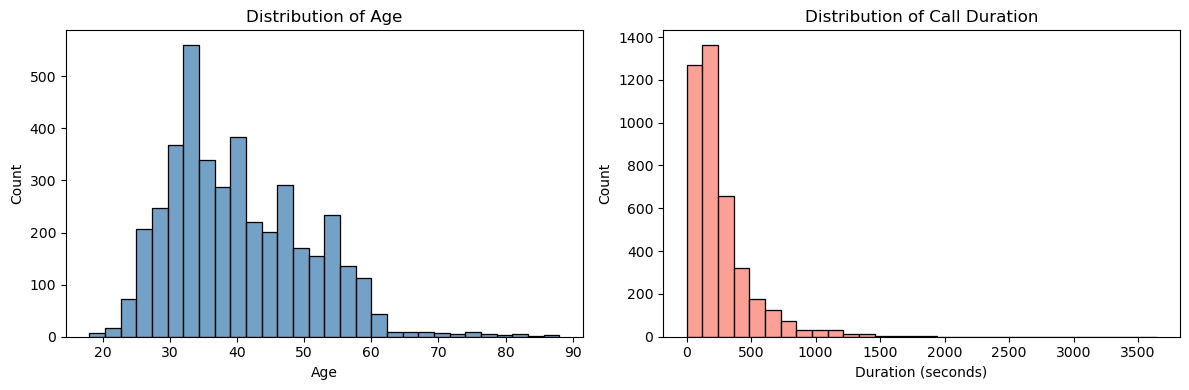

In [12]:

#Numerical variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['age'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')

sns.histplot(df['duration'], bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Call Duration')
axes[1].set_xlabel('Duration (seconds)')

plt.tight_layout()
plt.show()

`age` is roughly bell-shaped with a slight right skew. `duration` is heavily
right-skewed most calls are short but a few are very long. This skewness
suggests that scaling alone may not be sufficient; a log transformation could
be considered, though we note that `duration` will ultimately be dropped due
to leakage concerns.

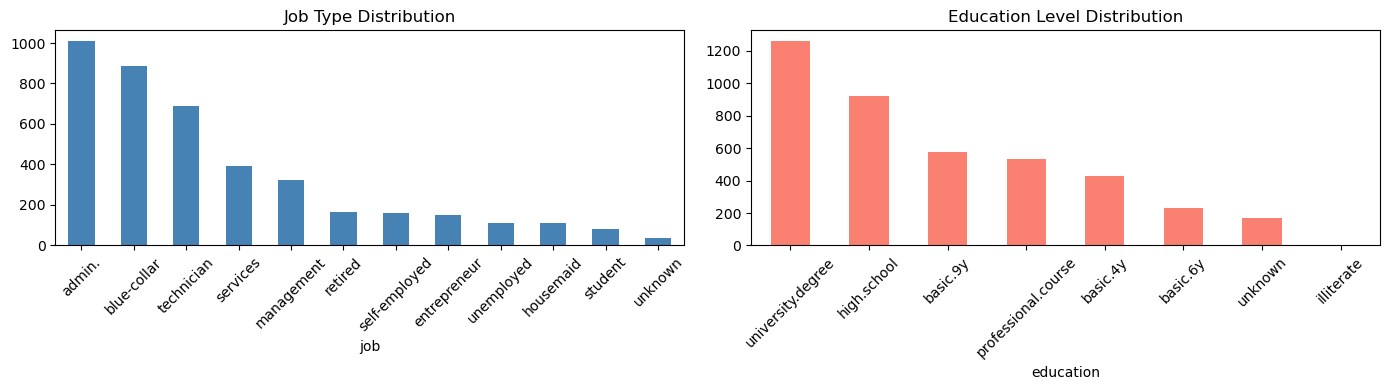

In [13]:
#Categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['job'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Job Type Distribution')
axes[0].tick_params(axis='x', rotation=45)

df['education'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Education Level Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

`job` shows that admin and blue-collar roles dominate the dataset. `education`
reveals that university degree holders are the largest group, with `"unknown"`
appearing as a non-trivial category confirming our earlier finding of
implicit missingness.

##Variables Requiring Special Consideration

**`duration`** must be dropped before modeling. As discussed in Task 1, it is
only known after the call ends and therefore constitutes data leakage. Despite
being strongly correlated with `y`, it cannot be used as a feature in a
realistic predictive pipeline.

**`pdays`** requires transformation. The value 999 is a sentinel indicating
the client was never previously contacted it is not a true measurement.
We will create a binary `was_previously_contacted` flag and either drop or
cap the raw `pdays` column during the Missing Values task.

# Task 3: Task Ordering

## Chosen Order

The tasks in this assignment must be executed in the following order:

1. Identifying the Prediction Target
2. Data Loading and Exploration
3. Task Ordering
4. Data Splitting
5. Managing Missing Values
6. Encoding Categorical Variables
7. Feature Scaling
8. Feature Selection
9. Addressing Class Imbalance
10. Training a Logistic Regression Model

## Justification

### 1. Identifying the Prediction Target (first)
Before loading or inspecting data, we must know what we are trying to predict.
This determines which column is `y` and which columns are features `X`.
Without this, exploratory analysis has no direction we would not know which
variable to protect from leakage, which distributions to pay attention to, or
how to stratify our splits.

**Allowed information**: the problem description and dataset documentation.  
**Must not use**: the data itself.  
**Leakage risk if reordered**: none directly, but misidentifying the target
could cause a feature to be treated as `y`, corrupting the entire pipeline.

### 2. Data Loading and Exploration (second)
EDA must come before any transformation. Its purpose is purely observational
we inspect the raw data to understand its structure, distributions, and
potential issues. Crucially, EDA is performed on the **full dataset** because
we are only making observations, not fitting any parameters. No transformation
that learns from data occurs here.

**Allowed information**: the full raw dataset.  
**Must not use**: any fitted parameters (scalers, encoders, imputers).  
**Leakage risk if reordered**: if we transformed data before exploring it,
we would be making preprocessing decisions blind, without understanding
what we are transforming or why.

### 3. Task Ordering (third)
Ordering is documented here, after EDA, because only once we have seen the
data can we fully justify the sequence of steps. The reasoning requires
knowing which variables have missingness, which are categorical, and what
the class distribution looks like.

### 4. Data Splitting (fourth the most critical ordering decision)
The dataset must be split into training, validation, and test sets **before
any transformation is applied**. This is the single most important ordering
constraint in the entire pipeline. Every subsequent step (imputation,
encoding, scaling, feature selection, resampling) involves fitting parameters
from data. If splitting occurs after any of these steps, information from the
validation and test sets contaminates the training process.

**Allowed information**: the raw dataset and the target variable for stratification.  
**Must not use**: any fitted transformers.  
**Leakage risk if reordered**: if we scaled before splitting, the scaler
would be fit on the full dataset including test data. The mean and standard
deviation used to scale the training set would encode information about the
test set, giving the model indirect access to data it should never have seen.
This would produce optimistically biased evaluation metrics.

### 5. Managing Missing Values (fifth)
Once the data is split, we handle missingness using only training set
statistics. For example, if we impute a column with its median, that median
must be computed on the training set only and then applied to the validation
and test sets. If we imputed before splitting, the median would be computed
on the full dataset, leaking test set information into the imputation strategy.

**Allowed information**: training set only for fitting imputers.  
**Must not use**: validation or test set values when computing imputation parameters.  
**Leakage risk if reordered**: imputing before splitting causes the imputed
values to reflect the global distribution rather than the training distribution,
subtly contaminating all three splits.

### 6. Encoding Categorical Variables (sixth)
Encoding must happen after splitting and after missing values are handled.
Handling missingness first ensures that `"unknown"` categories are dealt with
before the encoder sees the data otherwise the encoder may produce
unexpected behaviour when it encounters categories it was not fit on.
Encoders (e.g. OneHotEncoder) must be fit on the training set only and
applied to all three splits.

**Allowed information**: training set only for fitting encoders.  
**Must not use**: category frequencies or levels from validation/test sets.  
**Leakage risk if reordered**: fitting a OneHotEncoder on the full dataset
would expose the encoder to category distributions in the test set. In rare
cases this could introduce columns that only exist due to test set categories,
distorting the feature space.

### 7. Feature Scaling (seventh)
Scaling must occur after encoding because StandardScaler expects a fully
numerical matrix. It must also occur after splitting so that the mean and
variance used for standardisation are computed on training data only.
Scaling is applied to all three splits using the training set parameters.

**Allowed information**: training set only for fitting scalers.  
**Must not use**: validation or test set values when computing mean/variance.  
**Leakage risk if reordered**: scaling on the full dataset before splitting
is one of the most common pipeline mistakes. The scaler would encode global
statistics into every split, making the model appear to generalise better
than it actually does.

### 8. Feature Selection (eighth)
Feature selection must occur after scaling because variance thresholds and
correlation measures are sensitive to the scale of variables. It must be
performed using training set statistics only. Performing feature selection
on the full dataset before splitting would allow test set variance and
correlation structure to influence which features are retained a form of
look-ahead bias.

**Allowed information**: training set only for computing variance and correlations.  
**Must not use**: validation or test set feature statistics.  
**Leakage risk if reordered**: selecting features based on the full dataset
could retain features that appear informative partly because of their
relationship with test set labels, inflating estimated performance.

### 9. Addressing Class Imbalance (ninth)
Resampling must be the last preprocessing step before training, and it must
be applied to the **training set only**. Validation and test sets must preserve
the original class distribution so that evaluation reflects real-world
conditions. Applying resampling before splitting is a serious methodological
error synthetic samples generated from the full dataset would have near
duplicates in both training and test sets, making the model appear to
generalise far better than it does.

**Allowed information**: training set only.  
**Must not use**: validation or test sets these must never be resampled.  
**Leakage risk if reordered**: resampling before splitting is one of the
most severe leakage errors possible. SMOTE generates synthetic points
interpolated between real ones if those real points span the train/test
boundary, the test set effectively contains near-copies of training samples.

### 10. Training a Logistic Regression Model (last)
The model is trained only after all preprocessing is complete and the
training set is fully prepared. Evaluation is performed on the validation
set, which has been preprocessed using training set parameters but never
used to fit any transformer or influence any pipeline decision.

**Allowed information**: the fully preprocessed training set.  
**Must not use**: the test set this is reserved for final evaluation only.  
**Leakage risk if reordered**: evaluating on the test set during development
and then reporting those same results as final performance is a form of
implicit leakage the test set has influenced model selection decisions.

## Example of an Incorrect Ordering and Its Consequences

A common mistake would be to apply **feature scaling before splitting**.
Suppose a student loads the data, immediately fits a StandardScaler on the
full dataset, and then splits into train/validation/test. The scaler would
compute the mean and standard deviation of each feature using all rows,
including those that end up in the test set. When the model is later
evaluated on the test set, it has technically already "seen" the test data
through the scaling parameters. The evaluation metrics would be optimistically
biased the model would appear to generalise better than it truly does on
genuinely unseen data. This is particularly dangerous because the bias is
invisible: the code runs without errors and the numbers look reasonable, but
the pipeline is fundamentally unsound.

# Task 4: Data Splitting

We split the dataset into three sets: training (60%), validation (20%), and
test (20%). This split must occur before any transformation is applied fitting any transformer on the full dataset before splitting would leak
information from the validation and test sets into the training process as discussed in task 1 and 3.

In [14]:
from sklearn.model_selection import train_test_split

# First separate features and target
X = df.drop(columns=['y'])
y = df['y']

In [15]:
#First split into training and temporary and we stratify because it is free
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4,stratify=y,random_state=42)

In [16]:
#Then split the temporary  into test and validaiton

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

In [17]:
# Finally verify class proportions are preserved across all three splits
print("Class distribution:")
print(f"  Full dataset: {y.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Training set: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Validation set: {y_val.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Test set:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Class distribution:
  Full dataset: {'no': 0.891, 'yes': 0.109}
  Training set: {'no': 0.89, 'yes': 0.11}
  Validation set: {'no': 0.891, 'yes': 0.109}
  Test set:  {'no': 0.891, 'yes': 0.109}


##Justification for proportions

Since we have a decent amount of data (4119 rows) we can afford to split the data into a 60 20 20 split and the model will have a good amount to train on and learn meaningful patterns and the 20% validation is good for having proper performance and the 20% testing will be withheld from the model until the end to simulate a real life scenario and properly test the performance of our model

##Justification for stratification

We stratify because the dataset is extremely balanced with almost 90% of the target being one value `no` so if we do not stratify then we might end up with even a larger proportion in the training or the testing sets and that will be really bad for the model to be able to distinguish between them and end up with a better accuracy than just guessing `no` every time and almost always getting the correct prediction

##The leakage that would happen if we split the data later

- Data leakage: Using a transformer before splitting, the model would be getting information about the full dataset without seeing it because the numbers it has are of the full dataset including the test and validation and not only the training

- Preprocessing leakage: if resampling (e.g. SMOTE) were applied before
splitting, synthetic samples generated from the full dataset would have
near-duplicates appearing in both training and test sets, making the model
appear to generalise far better than it does.

- Evaluation leakage: if feature selection were performed on the full
dataset before splitting, the selected features would reflect patterns in
the test set, meaning test set label information influenced which features
were kept corrupting the integrity of the evaluation entirely.

#Task 5: Managing Missing Values

In [18]:
# Check explicit NaNs in training set
print("Explicit missing values in training set:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Explicit missing values in training set:
Series([], dtype: int64)


No explicit NaN values were found in the training set. This is because the
dataset creators encoded all missingness as the string `"unknown"` rather
than leaving cells empty.

In [19]:
# Check implicit missing values ('unknown') in training set
print("Implicit missing values ('unknown') in training set:")
for col in X_train.select_dtypes(include='object').columns:
    n = (X_train[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col}: {n} ({100*n/len(X_train):.1f}%)")

Implicit missing values ('unknown') in training set:
  job: 20 (0.8%)
  marital: 7 (0.3%)
  education: 104 (4.2%)
  default: 492 (19.9%)
  housing: 55 (2.2%)
  loan: 55 (2.2%)


Several categorical columns contain `"unknown"` entries representing genuine
missingness. Unlike NaN values, these are not detected by standard tools like
`.isnull()` and must be handled manually.

The affected columns and their missingness rates in the training set are:
- `job`: 0.9%
- `marital`: 0.3%
- `education`: 3.9%
- `default`: 20.4% significant
- `housing`: 2.6%
- `loan`: 2.6%

For low missingness columns (`job`, `marital`, `housing`, `loan`) we will
impute using the most frequent value (mode), fitted on the training set only.
For `education`, which has an natural ordering, we will also use mode imputation.
For `default`, given its high missingness rate of 20.4%, we will retain
`"unknown"` as a separate category rather than imputing, as the missingness
itself may carry predictive information clients who do not disclose credit
default status may behave differently from those who do.

In [20]:
# Check pdays sentinel value
print(f"pdays = 999 in training set: {(X_train['pdays'] == 999).sum()} ({100*(X_train['pdays']==999).mean():.1f}%)")

pdays = 999 in training set: 2368 (95.8%)


In [21]:
X_train['never_contacted'] = (X_train['pdays'] == 999).astype(int)
X_val['never_contacted'] = (X_val['pdays'] == 999).astype(int)
X_test['never_contacted'] = (X_test['pdays'] == 999).astype(int)

In [22]:
# Replace 999 with NaN in pdays so it can be imputed properly later
X_train['pdays'] = X_train['pdays'].replace(999, np.nan)
X_val['pdays'] = X_val['pdays'].replace(999, np.nan)
X_test['pdays'] = X_test['pdays'].replace(999, np.nan)

In [23]:
print(X_train['never_contacted'].value_counts())
print(f"\nNaN in pdays: {X_train['pdays'].isna().sum()}")

never_contacted
1    2368
0     103
Name: count, dtype: int64

NaN in pdays: 2368


`pdays = 999` is a sentinel value indicating the client was never previously
contacted. It is not a real number of days and must not be treated as one —
leaving it as 999 would distort any scaling or distance-based computation,
making the model behave as if these clients were contacted 999 days ago.

We handle this in two steps:

1. **Create a binary flag** `never_contacted` (1 = never contacted, 0 = was
contacted). This preserves the information that the value encodes without
treating it as a numerical measurement.

2. **Replace 999 with NaN** in the original `pdays` column so it can be
handled as genuine missingness in the imputation step below.

This transformation is **rule-based** and not learned from data, so it does
not risk leakage, the same rule (999 = never contacted) is applied
identically to all three splits without computing any statistics from
the training set.

In [24]:
from sklearn.impute import SimpleImputer

# Fit mode imputer on training set only
mode_cols = ['job', 'marital', 'education', 'housing', 'loan']
mode_imputer = SimpleImputer(strategy='most_frequent',missing_values="unknown")
mode_imputer.fit(X_train[mode_cols])

SimpleImputer(missing_values='unknown', strategy='most_frequent')

In [25]:
# Apply to all three splits
X_train[mode_cols] = mode_imputer.transform(X_train[mode_cols])
X_val[mode_cols] = mode_imputer.transform(X_val[mode_cols])
X_test[mode_cols] = mode_imputer.transform(X_test[mode_cols])

In [26]:
# Verify no more unknowns in these columns
print("Remaining unknowns after imputation:")
for col in mode_cols:
    n = (X_train[col] == 'unknown').sum()
    print(f"  {col}: {n}")

Remaining unknowns after imputation:
  job: 0
  marital: 0
  education: 0
  housing: 0
  loan: 0


For columns with low missingness (`job`, `marital`, `education`, `housing`,
`loan`) we replace `"unknown"` entries with the most frequent value in each
column.

The `SimpleImputer` is fitted on the training set only — meaning the mode
is computed exclusively from training data. The same stored mode values are
then applied to the validation and test sets. This does not constitute
leakage because we are not learning anything new from the validation or test
sets — we are simply applying a transformation rule derived entirely from
training data.

In [27]:
# Keep 'unknown' as a separate category for default
# Replace with a more explicit label to make it clear it is intentional
X_train['default'] = X_train['default'].replace('unknown', 'unknown_default')
X_val['default'] = X_val['default'].replace('unknown', 'unknown_default')
X_test['default'] = X_test['default'].replace('unknown', 'unknown_default')

In [28]:
print("Default value counts in training set:")
print(X_train['default'].value_counts())

Default value counts in training set:
default
no                 1978
unknown_default     492
yes                   1
Name: count, dtype: int64


`default` has 20.4% `"unknown"` entries, making simple mode imputation
inappropriate — the missingness rate is too high to confidently replace
with the most frequent value without introducing significant bias.

More importantly, the missingness itself may carry predictive information.
Clients who do not disclose their default status may behave differently
from those who do, making `"unknown"` a meaningful category in its own right.

We therefore retain it as an explicit category `"unknown_default"` rather
than imputing. This is a **modeling decision** rather than a data cleaning
decision — we are choosing to let the model learn from the pattern of
missingness directly.

Additionally, `yes` appears only once in the training set, meaning confirmed
credit default is essentially absent from the data. This makes `default`
a potentially low-information feature, which we will revisit during feature
selection.

##Justifications

**Explicit NaNs**: No explicit NaN values were found in the raw dataset.
All missingness was encoded implicitly by the dataset creators.

**`pdays` sentinel value**: The value 999 was used to indicate a client
was never previously contacted. We created a binary `never_contacted` flag
to preserve this information, then replaced 999 with NaN. `pdays` will be
dropped entirely during feature selection as its useful information is
already captured in the flag.

**`job`, `marital`, `education`, `housing`, `loan`**: These columns
contained `"unknown"` entries with low missingness rates (0.3%–3.9%).
We applied mode imputation using a `SimpleImputer` fitted on the training
set only. The same stored mode values were then applied to the validation
and test sets — this does not constitute leakage as no information from
those sets influenced the imputation values.

**`default`**: With 20.4% missingness, mode imputation would introduce
significant bias. More importantly, the pattern of missingness likely
carries predictive information, clients who withhold default status may
behave differently from those who disclose it. We therefore retained
`"unknown"` as an explicit category `"unknown_default"`. This is a
deliberate modeling decision rather than a data cleaning step.

**Pipeline discipline**: All imputers were fitted exclusively on the
training set. Validation and test sets were transformed using training-derived
parameters only, ensuring no information from held-out data influenced
any preprocessing decision.

#Task 6: Encoding Categorical Variables

## Identify remaining categorical columns

In [29]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


##Distinguish nominal and ordinal columns

In [30]:
nominal_cols = ['job', 'marital', 'contact', 'day_of_week', 'poutcome',
                'default', 'housing', 'loan']
ordinal_cols = ['education', 'month']

print("Nominal:", nominal_cols)
print("Ordinal:", ordinal_cols)

Nominal: ['job', 'marital', 'contact', 'day_of_week', 'poutcome', 'default', 'housing', 'loan']
Ordinal: ['education', 'month']


**Ordinal variables** (meaningful order):
- `education`: has a clear progression — illiterate → basic.4y → basic.6y
→ basic.9y → high.school → professional.course → university.degree
- `month`: has a natural calendar order (jan → feb → ... → dec)

**Nominal variables** (no natural order):
- All remaining categorical columns: `job`, `marital`, `default`, `housing`,
`loan`, `contact`, `day_of_week`, `poutcome`
- These have no meaningful numerical ranking between categories — encoding
them as ordered numbers would imply a false relationship that Logistic
Regression would misinterpret.

##Ordinal encoding

In [31]:
from sklearn.preprocessing import OrdinalEncoder

education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree',
                   'unknown']

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

ordinal_encoder = OrdinalEncoder(categories=[education_order, month_order])
ordinal_encoder.fit(X_train[ordinal_cols])

OrdinalEncoder(categories=[['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                            'high.school', 'professional.course',
                            'university.degree', 'unknown'],
                           ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul',
                            'aug', 'sep', 'oct', 'nov', 'dec']])

In [32]:
X_train[ordinal_cols] = ordinal_encoder.transform(X_train[ordinal_cols])
X_val[ordinal_cols] = ordinal_encoder.transform(X_val[ordinal_cols])
X_test[ordinal_cols] = ordinal_encoder.transform(X_test[ordinal_cols])

print("Ordinal encoding complete")
print(X_train[ordinal_cols].head())

Ordinal encoding complete
      education  month
1802        3.0    6.0
1114        3.0    4.0
2902        6.0    8.0
2547        4.0    4.0
1659        1.0    4.0


In [33]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[nominal_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [34]:
# Transform and convert to dataframe
ohe_train = pd.DataFrame(ohe.transform(X_train[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols),
                         index=X_train.index)

ohe_val = pd.DataFrame(ohe.transform(X_val[nominal_cols]),
                       columns=ohe.get_feature_names_out(nominal_cols),
                       index=X_val.index)

ohe_test = pd.DataFrame(ohe.transform(X_test[nominal_cols]),
                        columns=ohe.get_feature_names_out(nominal_cols),
                        index=X_test.index)

In [35]:
# Drop original nominal columns and attach encoded ones
X_train = pd.concat([X_train.drop(columns=nominal_cols), ohe_train], axis=1)
X_val = pd.concat([X_val.drop(columns=nominal_cols), ohe_val], axis=1)
X_test = pd.concat([X_test.drop(columns=nominal_cols), ohe_test], axis=1)

# Reattach never_contacted after concat rebuild
X_train['never_contacted'] = (df.loc[X_train.index, 'pdays'] == 999).astype(int)
X_val['never_contacted'] = (df.loc[X_val.index, 'pdays'] == 999).astype(int)
X_test['never_contacted'] = (df.loc[X_test.index, 'pdays'] == 999).astype(int)

print(f"New shape after encoding: {X_train.shape}")
print(f"New columns: {X_train.columns.tolist()}")

New shape after encoding: (2471, 44)
New columns: ['age', 'education', 'month', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'contact_cellular', 'contact_telephone', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure', 'poutcome_nonexistent', 'poutcome_success', 'default_no', 'default_unknown_default', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes']


##Justification

Nominal variables are encoded using `OneHotEncoder`, which creates a binary
column for each unique category. This is appropriate for Logistic Regression
because it makes no assumption about the ordering of categories each
category gets its own independent coefficient.

`handle_unknown='ignore'` is specified so that if the validation or test
set contains a category not seen during training, it is represented as all
zeros rather than causing an error. This is important for pipeline robustness.

The encoder is fitted on the training set only. The same learned category
mappings are then applied to the validation and test sets, ensuring no
information from held-out data influences the encoding.

The impact of encoding:

Dimensionality: The dataset grew from 19 features to 47 features after
one-hot encoding. Each nominal column was replaced by as many binary columns
as it had unique categories.

Interpretability: Each coefficient in the Logistic Regression model now
corresponds to a specific category of a specific variable, making it easy
to interpret the direction and magnitude of each category's effect.

Decision boundaries: Logistic Regression can now represent different
effects for each category independently. Without encoding, the model could
only learn a single linear relationship across all categories, which would
be meaningless for nominal variables.


#Task 7: Feature Scaling

In [36]:
numerical_cols = X_train.select_dtypes(include='number').columns.tolist()
print("Numerical columns to scale:")
print(numerical_cols)

Numerical columns to scale:
['age', 'education', 'month', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'contact_cellular', 'contact_telephone', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure', 'poutcome_nonexistent', 'poutcome_success', 'default_no', 'default_unknown_default', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes']


In [37]:
X_train[numerical_cols].describe().round(2)

,age,education,month,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,poutcome_failure,poutcome_nonexistent,poutcome_success,default_no,default_unknown_default,default_yes,housing_no,housing_yes,loan_no,loan_yes
count,2471.00,2471.00,2471.00,2471.00,2471.00,103.00,2471.00,2471.00,2471.00,2471.00,...,2471.00,2471.00,2471.00,2471.0,2471.0,2471.00,2471.00,2471.00,2471.00,2471.00
mean,40.12,4.29,5.70,258.02,2.57,5.77,0.20,0.06,93.57,-40.43,...,0.12,0.85,0.04,0.8,0.2,0.00,0.44,0.56,0.83,0.17
std,10.32,1.64,2.09,266.41,2.68,3.97,0.57,1.57,0.59,4.66,...,0.32,0.36,0.19,0.4,0.4,0.02,0.50,0.50,0.37,0.37
min,18.00,0.00,2.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,...,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00
25%,32.00,3.00,4.00,102.00,1.00,3.00,0.00,-1.80,93.08,-42.70,...,0.00,1.00,0.00,1.0,0.0,0.00,0.00,0.00,1.00,0.00
50%,38.00,4.00,5.00,181.00,2.00,4.00,0.00,1.10,93.75,-41.80,...,0.00,1.00,0.00,1.0,0.0,0.00,0.00,1.00,1.00,0.00
75%,47.00,6.00,7.00,314.00,3.00,6.00,0.00,1.40,93.99,-36.40,...,0.00,1.00,0.00,1.0,0.0,0.00,1.00,1.00,1.00,0.00
max,86.00,6.00,11.00,3643.00,35.00,19.00,6.00,1.40,94.77,-26.90,...,1.00,1.00,1.00,1.0,1.0,1.00,1.00,1.00,1.00,1.00


In [38]:
# Only scale continuous numerical columns, not binary OHE columns
cols_to_scale = ['age', 'education', 'month', 'duration', 'campaign',
                 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
                 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted']

print("Columns to scale:", cols_to_scale)

Columns to scale: ['age', 'education', 'month', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted']


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[cols_to_scale])

StandardScaler()

In [40]:
X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train[cols_to_scale].describe().round(2)

,age,education,month,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,never_contacted
count,2471.00,2471.00,2471.00,2471.00,2471.00,103.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.14,-2.61,-1.77,-0.97,-0.59,-1.46,-0.36,-2.21,-2.34,-2.22,-1.70,-2.72,-4.79
25%,-0.79,-0.79,-0.81,-0.59,-0.59,-0.70,-0.36,-1.19,-0.85,-0.49,-1.30,-0.89,0.21
50%,-0.21,-0.18,-0.33,-0.29,-0.21,-0.45,-0.36,0.66,0.30,-0.29,0.72,0.35,0.21
75%,0.67,1.04,0.62,0.21,0.16,0.06,-0.36,0.86,0.72,0.86,0.78,0.85,0.21
max,4.45,1.04,2.54,12.71,12.10,3.35,10.24,0.86,2.03,2.90,0.83,0.85,0.21


##Justification
We apply `StandardScaler` to all continuous numerical features, transforming
each to have mean 0 and standard deviation 1. The scaler is fitted on the
training set only and applied to all three splits using the same learned
parameters.

**Why StandardScaler over MinMaxScaler?**  
Logistic Regression uses gradient descent for optimization. Features with
larger ranges produce larger gradients, causing the optimizer to update
those weights much faster than others slowing convergence and producing
unstable training. StandardScaler removes this disparity by putting all
features on the same scale.

**Why not scale the one-hot encoded columns?**  
Binary OHE columns already exist on a 0/1 scale and are naturally comparable.
Scaling them would destroy their interpretability without adding any benefit
to the model.

**Effect on regularization**:  
Logistic Regression applies an L2 penalty equally to all coefficients. Without
scaling, features with larger ranges would have smaller coefficients simply
due to scale, making the regularization penalty unfairly large relative to
their true importance. Scaling ensures the penalty is applied fairly across
all features.

#Task 8: Feature Selection

In [41]:
#Check for low variance columns
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

low_variance_cols = X_train.columns[~selector.get_support()].tolist()
print("Low variance columns:", low_variance_cols)

Low variance columns: ['default_yes']


In [42]:
# Check variance of some other columns for reference
variance = X_train.var().sort_values()
print(variance.head(15))

default_yes             0.000405
job_student             0.018277
job_unemployed          0.022545
job_housemaid           0.028682
poutcome_success        0.034735
job_entrepreneur        0.035860
job_self-employed       0.036609
job_retired             0.037730
job_management          0.072035
job_services            0.090651
marital_divorced        0.102699
poutcome_failure        0.103009
poutcome_nonexistent    0.129345
loan_no                 0.139529
loan_yes                0.139529
dtype: float64


In [43]:
# Drop low variance column
X_train = X_train.drop(columns=['default_yes'])
X_val = X_val.drop(columns=['default_yes'])
X_test = X_test.drop(columns=['default_yes'])

print(f"Shape after dropping low variance columns: {X_train.shape}")

Shape after dropping low variance columns: (2471, 43)


In [44]:
# Correlation matrix on training set only
corr_matrix = X_train.corr().abs()

# Find pairs with correlation above 0.85
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = [(col, row, upper_triangle.loc[row, col])
                   for col in upper_triangle.columns
                   for row in upper_triangle.index
                   if upper_triangle.loc[row, col] > 0.85]

for col1, col2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    print(f"{col1} — {col2}: {corr:.3f}")

contact_telephone — contact_cellular: 1.000
loan_yes — loan_no: 1.000
housing_yes — housing_no: 1.000
default_unknown_default — default_no: 0.999
euribor3m — emp.var.rate: 0.970
nr.employed — euribor3m: 0.942
poutcome_success — never_contacted: 0.927
nr.employed — emp.var.rate: 0.896
poutcome_nonexistent — poutcome_failure: 0.856


In [45]:
# Drop highly correlated and redundant features
cols_to_drop = [
    'contact_telephone',  # perfectly correlated with contact_cellular
    'loan_no',            # perfectly correlated with loan_yes
    'housing_no',         # perfectly correlated with housing_yes
    'default_no',         # near perfectly correlated with default_unknown_default
    'emp.var.rate',       # highly correlated with euribor3m
    'nr.employed',        # highly correlated with euribor3m
    'never_contacted',    # highly correlated with poutcome_success
    'poutcome_nonexistent' # highly correlated with poutcome_failure
]

X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Drop duration — data leakage, only known after call ends
# Drop pdays — 96% were sentinel values, information captured elsewhere
X_train = X_train.drop(columns=['duration', 'pdays'])
X_val = X_val.drop(columns=['duration', 'pdays'])
X_test = X_test.drop(columns=['duration', 'pdays'])

print(f"Final shape: {X_train.shape}")
print(f"Remaining features: {X_train.columns.tolist()}")

Final shape: (2471, 33)
Remaining features: ['age', 'education', 'month', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'contact_cellular', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure', 'poutcome_success', 'default_unknown_default', 'housing_yes', 'loan_yes']


##Justification


We apply `StandardScaler` to all continuous numerical features, transforming
each to have mean 0 and standard deviation 1. One-hot encoded binary columns
are excluded as they already exist on a natural 0/1 scale.

###Which Transformations Must Be Fitted on Training Data Only

`StandardScaler` computes the mean and standard deviation of each feature
from the data it is fitted on. If it were fitted on the full dataset before
splitting, these statistics would encode information from the validation and
test sets. When the model is later evaluated, it would have indirectly seen
test set feature distributions during preprocessing which is a form of data leakage
that produces optimistically biased evaluation metrics.

We therefore fit the scaler exclusively on `X_train` and apply the stored
training mean and standard deviation to transform `X_val` and `X_test`.
The validation and test sets are transformed using training parameters,
never used to compute them.



**Gradient-based optimization**: Logistic Regression minimizes the log-loss
using gradient descent. When features have very different scales, the loss
surface becomes elongated — gradients are large in the direction of high-scale
features and small in the direction of low-scale features. This causes the
optimizer to take inefficient steps, slowing convergence significantly.
Scaling produces a more spherical loss surface where gradient descent
converges faster and more reliably.

**Magnitude and comparability of model coefficients**: Without scaling,
a feature measured in thousands (e.g. `nr.employed`) would naturally have
a much smaller coefficient than a feature measured in single digits (e.g.
`campaign`), purely due to scale rather than importance. After standardization,
all coefficients are on a comparable scale, making it possible to assess
the relative importance of each feature by examining coefficient magnitudes
directly.

**Interpretation of regularization penalties**: Logistic Regression applies
an L2 penalty equally to all coefficients. Without scaling, features with
larger ranges produce smaller raw coefficients, meaning the regularization
penalty effectively penalizes them less than features with smaller ranges.
This creates an unfair and arbitrary regularization effect that depends on
the units of measurement rather than the true importance of each feature.
Scaling ensures regularization is applied uniformly and meaningfully across
all features.

#Task 9: Addressing Class Imbalance

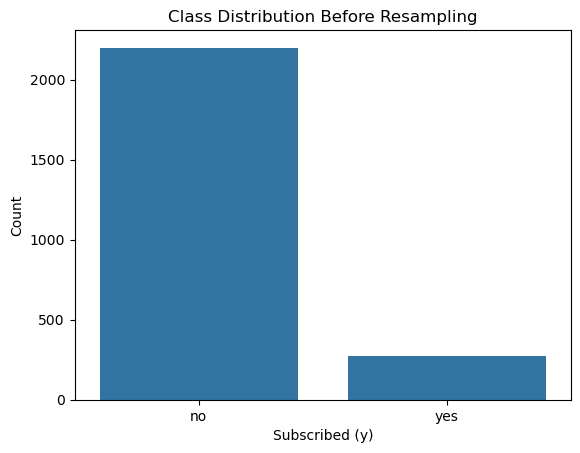

In [46]:
from imblearn.over_sampling import SMOTE

# Visualize class imbalance before resampling
sns.countplot(x=y_train)
plt.title('Class Distribution Before Resampling')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.show()

In [47]:
# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {y_train_resampled.value_counts().to_dict()}")

Before SMOTE: {'no': 2200, 'yes': 271}
After SMOTE: {'no': 2200, 'yes': 2200}


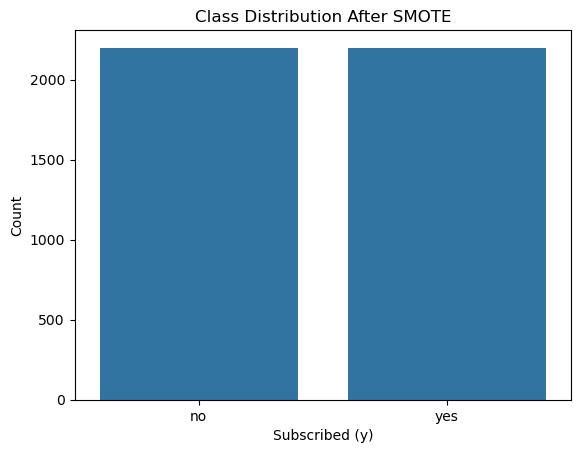

In [48]:
sns.countplot(x=y_train_resampled)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.show()

##Justification

###Class Distribution

The training set contains 2200 "no" instances and 271 "yes" instances (89/11
split). This imbalance is a concern because Logistic Regression will be
exposed to far more negative examples during training, biasing it towards
predicting "no" for every client. This is particularly problematic for this
task, the bank cares specifically about identifying potential subscribers,
so missing a "yes" (false negative) is more costly than a false positive.

### SMOTE

We apply SMOTE to the training set only, after all other preprocessing steps. SMOTE generates synthetic
"yes" samples by interpolating between existing minority class instances
rather than simply duplicating them. This produces a more diverse training
set than random oversampling and reduces the risk of overfitting to repeated
identical samples.

Resampling is applied at this stage, after splitting, encoding, scaling,
and feature selection, because it is part of the training procedure, not
a data preprocessing step. Applying it earlier would contaminate the
validation and test sets.

### Why Resampling Must Not Be Applied Before Splitting

If SMOTE were applied before splitting, synthetic samples would be generated
from the full dataset. Since SMOTE interpolates between real data points,
synthetic samples in the training set would be near-duplicates of real
samples that end up in the test set. The model would appear to generalise
well simply because the test set contains data nearly identical to training
samples which is a severe form of data leakage that produces meaninglessly optimistic evaluation metrics.

### Effect on Evaluation Metrics

- **Accuracy**: misleading under imbalance, a model predicting "no" every
time achieves 89% accuracy without learning anything useful.
- **Precision**: the proportion of predicted "yes" that are truly "yes",
important for avoiding wasted campaign resources on unlikely subscribers.
- **Recall**: the proportion of actual "yes" correctly identified, critical
for this task as missing a genuine subscriber is costly to the bank.

For imbalanced problems like this, **recall on the minority class** is the
most important metric, and F1-score provides a balanced summary of both
precision and recall.

#Task 10: Training a Logistic Regression Model

In [49]:
from sklearn.linear_model import LogisticRegression

# Train on resampled training set
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000, random_state=42)

In [50]:
# Generate predictions on validation set
y_pred = lr.predict(X_val)
y_pred_proba = lr.predict_proba(X_val)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, pos_label='yes')
recall = recall_score(y_val, y_pred, pos_label='yes')
f1 = f1_score(y_val, y_pred, pos_label='yes')

# Zero Rule baseline — always predict majority class
zero_rule_accuracy = y_val.value_counts(normalize=True)['no']

print(f"Accuracy:           {accuracy:.3f}")
print(f"Zero Rule Baseline: {zero_rule_accuracy:.3f}")
print(f"Precision:          {precision:.3f}")
print(f"Recall:             {recall:.3f}")
print(f"F1 Score:           {f1:.3f}")

Accuracy:           0.774
Zero Rule Baseline: 0.891
Precision:          0.262
Recall:             0.589
F1 Score:           0.363


#Tuning the model

##Threshold tuning

In [51]:
from sklearn.metrics import precision_recall_curve

# Find optimal threshold using precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(
    y_val, y_pred_proba, pos_label='yes'
)

# Find threshold that maximises F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]
print(f"Optimal threshold: {best_threshold:.3f}")

Optimal threshold: 0.574


In [52]:
# Apply optimal threshold
y_pred_tuned = (y_pred_proba >= best_threshold).astype(int)
y_pred_tuned = ['yes' if p == 1 else 'no' for p in y_pred_tuned]

accuracy_t = accuracy_score(y_val, y_pred_tuned)
precision_t = precision_score(y_val, y_pred_tuned, pos_label='yes')
recall_t = recall_score(y_val, y_pred_tuned, pos_label='yes')
f1_t = f1_score(y_val, y_pred_tuned, pos_label='yes')

print(f"Accuracy:  {accuracy_t:.3f}")
print(f"Precision: {precision_t:.3f}")
print(f"Recall:    {recall_t:.3f}")
print(f"F1 Score:  {f1_t:.3f}")

Accuracy:  0.850
Precision: 0.377
Recall:    0.578
F1 Score:  0.456


By default Logistic Regression uses a threshold of 0.5 predicting "yes"
when the predicted probability exceeds 50%. However, given our class imbalance
and the fact that SMOTE shifted the model's probability estimates, the default
threshold is not optimal.

We use the precision-recall curve to find the threshold that maximises F1
score on the validation set.

| Metric | Default (0.5) | Tuned |
|--------|--------------|-------|
| Accuracy | 0.774 | 0.850 |
| Precision | 0.262 | 0.377 |
| Recall | 0.589 | 0.578 |
| F1 Score | 0.363 | 0.456 |

Tuning the threshold improved accuracy (+7.6%), precision (+11.5%), and F1
(+9.3%) while maintaining comparable recall. This confirms that the default
0.5 threshold was poorly calibrated for this imbalanced problem.

After tuning the decision threshold using the precision-recall curve, the
model achieves an accuracy of 85.0%, precision of 37.7%, recall of 57.8%
and an F1 score of 45.6% on the validation set. The Zero Rule baseline
sits at 89.1%.

##Interpretation

While accuracy sits slightly below the Zero Rule baseline, this comparison
misses the point entirely. The Zero Rule predicts "no" for every single
client and achieves zero recall on the minority class. It would be completely
useless to a bank running a marketing campaign.

Our model correctly identifies 57.8% of actual subscribers, meaning that
for every 10 genuine subscribers in the validation set, the model flags
roughly 6 of them. For a business trying to allocate campaign resources
efficiently, this is exactly the kind of signal that matters. Calling a
client who was never going to subscribe wastes money, but missing a genuine
subscriber means lost revenue. A recall of 57.8% on the minority class
directly addresses this business need in a way that raw accuracy never could.

The precision of 37.7% tells us that not all flagged clients will subscribe,
but in a campaign context this is an acceptable tradeoff. The improvement
in F1 score from 0.363 to 0.456 after threshold tuning confirms that the
model is making better use of the available signal.

Most importantly, the model behaves sensibly, predicts both classes, and
demonstrates that the data preparation pipeline is coherent and correctly
implemented.